In [1]:
%pip install ultralytics opencv-python pillow pandas numpy matplotlib --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 59.4 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print(root)

/kaggle/input
/kaggle/input/competitions
/kaggle/input/competitions/tom-jerry-object-detection
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test/images
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/annotations
/kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/images


In [3]:
from pathlib import Path
import os, json, random, shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml
import cv2
from ultralytics import YOLO
import torch

BASE_DIR = Path("/kaggle/working")
OUT_ROOT = BASE_DIR / "dataset"
OUT_ROOT.mkdir(parents=True, exist_ok=True)

INPUT_ROOT = Path(
    "/kaggle/input/competitions/tom-jerry-object-detection/"
    "Tom_and_Jerry_Kaggle_dataset/"
    "Tom_and_Jerry_Kaggle_dataset"
)

SRC_TRAIN_IMG = INPUT_ROOT / "train/images"
SRC_TRAIN_JSON = INPUT_ROOT / "train/annotations/train.json"
SRC_TEST_IMG = INPUT_ROOT / "test/images"

print("SRC_TRAIN_IMG:", SRC_TRAIN_IMG, "n=", len(list(SRC_TRAIN_IMG.glob("*.jpg"))))
print("SRC_TRAIN_JSON:", SRC_TRAIN_JSON, "exists=", SRC_TRAIN_JSON.exists())
print("SRC_TEST_IMG:", SRC_TEST_IMG, "n=", len(list(SRC_TEST_IMG.glob("*.jpg"))))

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
SRC_TRAIN_IMG: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/images n= 727
SRC_TRAIN_JSON: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/train/annotations/train.json exists= True
SRC_TEST_IMG: /kaggle/input/competitions/tom-jerry-object-detection/Tom_and_Jerry_Kaggle_dataset/Tom_and_Jerry_Kaggle_dataset/test/images n= 180


In [4]:
TRAIN_IMG_DIR = OUT_ROOT / "train/images"
TRAIN_LAB_DIR = OUT_ROOT / "train/labels"
VAL_IMG_DIR   = OUT_ROOT / "val/images"
VAL_LAB_DIR   = OUT_ROOT / "val/labels"

for p in [TRAIN_IMG_DIR, TRAIN_LAB_DIR, VAL_IMG_DIR, VAL_LAB_DIR]:
    p.mkdir(parents=True, exist_ok=True)

def hard_copy(src: Path, dst: Path):
    shutil.copy2(src, dst)

In [5]:
def coco_xywh_to_yolo_norm(bbox_xywh, W, H):
    x, y, w, h = bbox_xywh
    cx = (x + w / 2) / W
    cy = (y + h / 2) / H
    bw = w / W
    bh = h / H
    # clip
    cx = float(np.clip(cx, 0.0, 1.0))
    cy = float(np.clip(cy, 0.0, 1.0))
    bw = float(np.clip(bw, 0.0, 1.0))
    bh = float(np.clip(bh, 0.0, 1.0))
    return cx, cy, bw, bh


with open(SRC_TRAIN_JSON, "r") as f:
    coco = json.load(f)

# 类别映射：COCO category_id -> 0..K-1
cats = sorted(coco["categories"], key=lambda x: x["id"])
catid2cls = {c["id"]: i for i, c in enumerate(cats)}
class_names = [c["name"] for c in cats]
print("Classes:", class_names)

# image_id -> info
imgid2info = {im["id"]: im for im in coco["images"]}

# image_id -> annotations
imgid2anns = {}
for ann in coco["annotations"]:
    imgid2anns.setdefault(ann["image_id"], []).append(ann)

# split
all_ids = list(imgid2info.keys())
random.seed(42)
random.shuffle(all_ids)

val_ratio = 0.1
n_val = int(len(all_ids) * val_ratio)
val_ids = set(all_ids[:n_val])
train_ids = all_ids[n_val:]

print("train:", len(train_ids), "val:", len(val_ids))

def write_label_txt(img_info, anns, out_txt: Path):
    W, H = img_info["width"], img_info["height"]
    lines = []
    for ann in anns:
        if "bbox" not in ann:
            continue
        cls = catid2cls[ann["category_id"]]
        cx, cy, bw, bh = coco_xywh_to_yolo_norm(ann["bbox"], W, H)
        lines.append(f"{cls} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}")
    out_txt.write_text("\n".join(lines) + ("\n" if lines else ""))

missing = 0
for img_id in all_ids:
    info = imgid2info[img_id]
    fname = info["file_name"]
    src_img = SRC_TRAIN_IMG / fname
    if not src_img.exists():
        missing += 1
        continue

    anns = imgid2anns.get(img_id, [])

    if img_id in val_ids:
        dst_img = VAL_IMG_DIR / src_img.name
        dst_txt = VAL_LAB_DIR / (src_img.stem + ".txt")
    else:
        dst_img = TRAIN_IMG_DIR / src_img.name
        dst_txt = TRAIN_LAB_DIR / (src_img.stem + ".txt")

    hard_copy(src_img, dst_img)
    write_label_txt(info, anns, dst_txt)

print("Done. missing:", missing)
print("train imgs:", len(list(TRAIN_IMG_DIR.glob("*.jpg"))), "val imgs:", len(list(VAL_IMG_DIR.glob("*.jpg"))))

Classes: ['Tom', 'Jerry']
train: 655 val: 72
Done. missing: 0
train imgs: 655 val imgs: 72


In [6]:
yaml_path = BASE_DIR / "dataset.yaml"

data_yaml = {
    "path": str(OUT_ROOT),
    "train": "train/images",
    "val": "val/images",
    "names": {i: n for i, n in enumerate(class_names)}
}

with open(yaml_path, "w") as f:
    yaml.safe_dump(data_yaml, f, sort_keys=False)

print("dataset.yaml saved:", yaml_path, "exists:", yaml_path.exists())
print(yaml_path.read_text())

dataset.yaml saved: /kaggle/working/dataset.yaml exists: True
path: /kaggle/working/dataset
train: train/images
val: val/images
names:
  0: Tom
  1: Jerry



In [7]:
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

model = YOLO("yolov8s.pt")

model.train(
    data=str(yaml_path),
    epochs=50,
    imgsz=640,      # 因为图像是 640×480
    batch=32,       # OOM 就改 16
    device=0,
    workers=4,
    amp=True,
    project="yolo_runs",
    name="tj_p100"
)

cuda available: True
gpu: Tesla P100-PCIE-16GB
Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=tj_p100, nbs=64, nms=False, opset=None, optimize=False, opti

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d4493af6840>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04804

[PosixPath('runs/detect/yolo_runs/tj_p100/val_batch1_pred.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/args.yaml'), PosixPath('runs/detect/yolo_runs/tj_p100/weights'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch0.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/results.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxR_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxF1_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/labels.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/results.csv'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch0_pred.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/confusion_matrix_normalized.png'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch1.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/val_batch0_labels.jpg'), PosixPath('runs/detect/yolo_runs/tj_p100/confusion_matrix.png'), PosixPath('runs/detect/yolo_runs/tj_p100/BoxP_curve.png'), PosixPath('runs/detect/yolo_runs/tj_p100/train_batch2.jpg'), PosixPath('runs/detect/yolo_ru

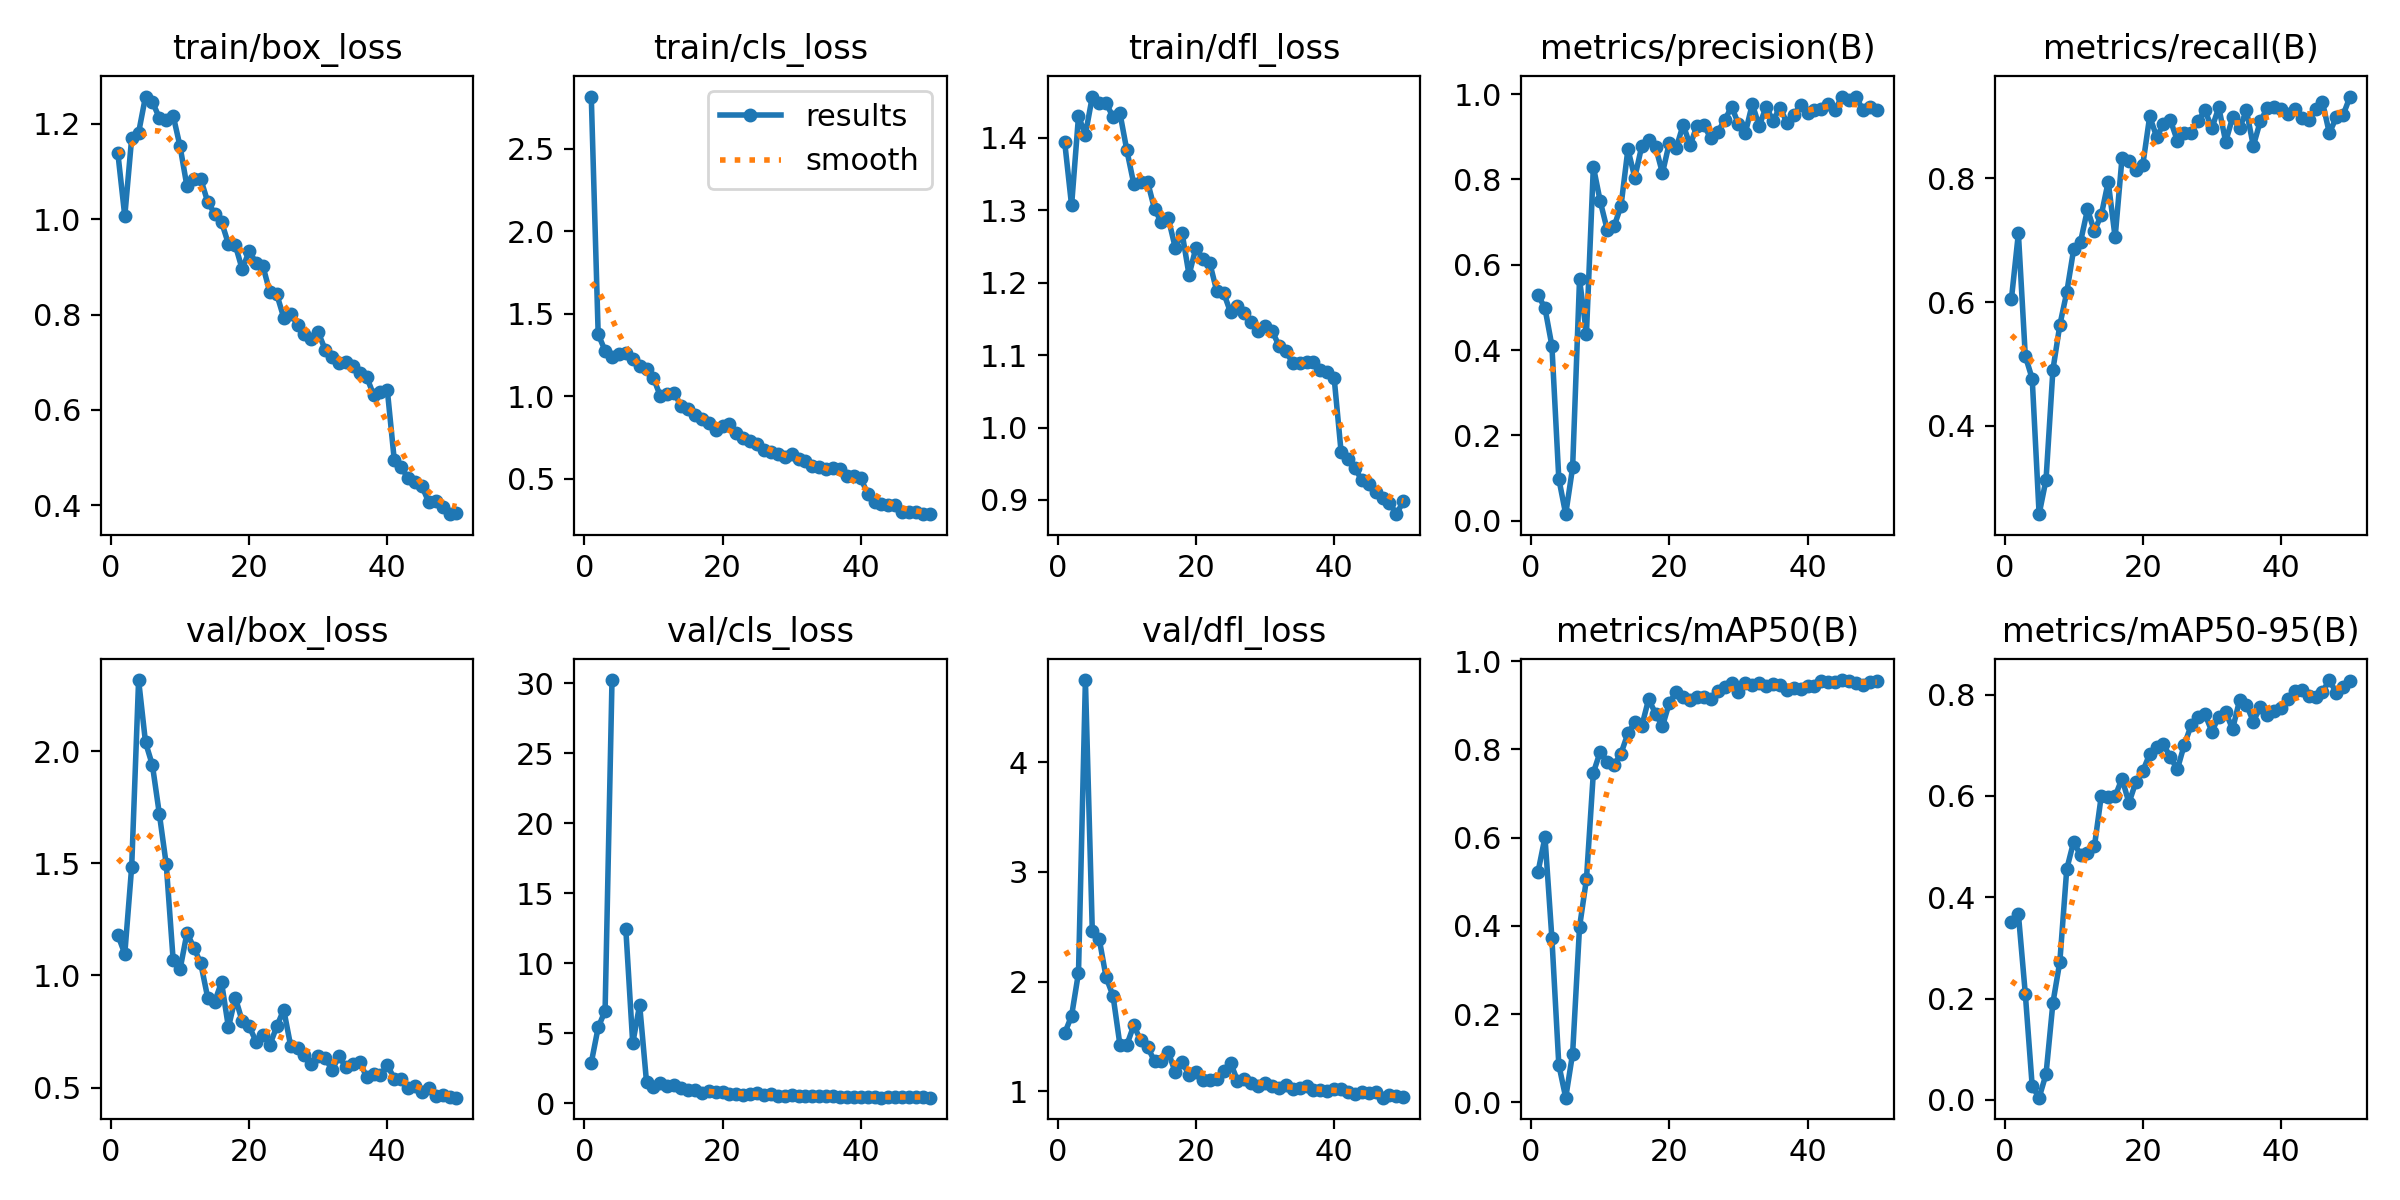

In [11]:
from pathlib import Path
from PIL import Image
from IPython.display import display

run_dir = Path("runs/detect/yolo_runs/tj_p100")

print(list(run_dir.iterdir()))

display(Image.open(run_dir / "results.png"))

In [13]:
best_pt = Path("runs/detect/yolo_runs/tj_p100/weights/best.pt")
model = YOLO(str(best_pt))

metrics = model.val(
    data=str(yaml_path),
    split="val",
    plots=True,
    device=0
)

print(metrics)
print("Check plots under:", Path("yolo_runs/tj_p100"))

Ultralytics 8.4.21 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
Model summary (fused): 73 layers, 11,126,358 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1637.6±380.8 MB/s, size: 53.5 KB)
val: Scanning /kaggle/working/dataset/val/labels.cache... 72 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 72/72 30.2Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 3.4it/s 1.5s0.4s
                   all         72         89      0.923      0.935      0.951      0.828
                   Tom         48         48      0.915      0.894      0.919      0.777
                 Jerry         41         41      0.931      0.976      0.983      0.878
Speed: 4.0ms preprocess, 6.8ms inference, 0.0ms loss, 4.5ms postprocess per image
Results saved to /kaggle/working/runs/detect/val
ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: a

In [14]:
best_pt = Path("runs/detect/yolo_runs/tj_p100/weights/best.pt")
model = YOLO(str(best_pt))

CONF_THR = 0.001

def clamp_int(x, lo, hi):
    return int(max(lo, min(int(round(float(x))), hi)))

pred_rows = []
test_imgs = sorted(list(SRC_TEST_IMG.glob("*.jpg")))
print("Test images:", len(test_imgs))

for img_path in test_imgs:
    image_id = img_path.stem
    im = cv2.imread(str(img_path))
    H, W = im.shape[:2]

    r = model.predict(source=str(img_path), conf=CONF_THR, iou=0.6, verbose=False, device=0)[0]

    dets = []
    if r.boxes is not None and len(r.boxes) > 0:
        xyxy = r.boxes.xyxy.cpu().numpy()
        conf = r.boxes.conf.cpu().numpy()
        cls  = r.boxes.cls.cpu().numpy()

        for (x1,y1,x2,y2), c, k in zip(xyxy, conf, cls):
            x1 = clamp_int(x1, 0, W)
            y1 = clamp_int(y1, 0, H)
            x2 = clamp_int(x2, 0, W)
            y2 = clamp_int(y2, 0, H)
            dets.append(f"{int(k)} {float(c):.4f} {x1} {y1} {x2} {y2}")

    if len(dets) == 0:
        # 兜底，避免有些比赛不允许空 PredictionString
        dets = ["0 0.001 0 0 1 1"]

    pred_rows.append({"image_id": image_id, "PredictionString": " ".join(dets)})

Test images: 180
Saved: submission.csv


,image_id,PredictionString
0,0107031a-AhSweetMouseStoryofLife19655460,0 0.9676 160 137 420 480 1 0.9063 155 268 240 ...
1,036051d4-MouseCleaning19485100,0 0.9387 231 195 624 459 0 0.0017 0 76 56 425
2,0cec82eb-TomicEnergy19657800,1 0.9506 187 152 342 307 0 0.0013 177 328 416 480
3,0e92459e-OnARoll2021900,1 0.7945 231 141 425 281 1 0.3130 187 69 425 2...
4,0f20d1c4-TomicEnergy19652400,1 0.9090 322 130 473 326 0 0.5961 0 0 451 354 ...


In [16]:
out_path = Path("/kaggle/working/submission.csv")
sub.to_csv(out_path, index=False)

print("Saved:", out_path)

Saved: /kaggle/working/submission.csv


In [18]:
from pathlib import Path

for p in Path("/kaggle/working").rglob("submission.csv"):
    print(p)

/kaggle/working/submission.csv
